In [1]:
# load the dataset path
import kagglehub
path = kagglehub.dataset_download("arashnic/hr-analytics-job-change-of-data-scientists")

print("Path to dataset files:", path)


100%|██████████| 295k/295k [00:00<00:00, 29.0MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/arashnic/hr-analytics-job-change-of-data-scientists/versions/1


In [2]:
# to know the files name
import os
print(os.listdir(path))

['aug_test.csv', 'sample_submission.csv', 'aug_train.csv']


In [3]:
# reading the training dataset
import pandas as pd

df = pd.read_csv(os.path.join(path, "aug_train.csv"))
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


In [4]:
# Select only the features required for the project
selected_columns = [
    'education_level',
    'experience',
    'company_type',
    'training_hours',
    'relevent_experience',
    'target'
]

df = df[selected_columns]

In [5]:
# show information about the dataset, including columns, data types, and non-null values
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   education_level      18698 non-null  object 
 1   experience           19093 non-null  object 
 2   company_type         13018 non-null  object 
 3   training_hours       19158 non-null  int64  
 4   relevent_experience  19158 non-null  object 
 5   target               19158 non-null  float64
dtypes: float64(1), int64(1), object(4)
memory usage: 898.2+ KB


In [6]:
# Count the number of missing values in each column
df.isnull().sum()

,0
education_level,460
experience,65
company_type,6140
training_hours,0
relevent_experience,0
target,0


In [7]:
# Check the distribution of the target variable (who will change his jop and who will not)
df['target'].value_counts(normalize=True) * 100

,proportion
target,
0.0,75.065247
1.0,24.934753


In [8]:
# Check the percentage of missing values in each column
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

,0
company_type,32.049274
education_level,2.401086
experience,0.339284
training_hours,0.000000
relevent_experience,0.000000
target,0.000000


In [9]:
# Check the unique categories in important categorical features
for col in [ 'education_level', 'experience', 'company_type' ]:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))


education_level:
education_level
Graduate          11598
Masters            4361
High School        2017
NaN                 460
Phd                 414
Primary School      308
Name: count, dtype: int64

experience:
experience
>20    3286
5      1430
4      1403
3      1354
6      1216
2      1127
7      1028
10      985
9       980
8       802
15      686
11      664
14      586
1       549
<1      522
16      508
12      494
13      399
17      342
19      304
18      280
20      148
NaN      65
Name: count, dtype: int64

company_type:
company_type
Pvt Ltd                9817
NaN                    6140
Funded Startup         1001
Public Sector           955
Early Stage Startup     603
NGO                     521
Other                   121
Name: count, dtype: int64


In [10]:
# Fill missing values in categorical features with 'Unknown'
categorical_cols = [ 'education_level', 'company_type', 'experience']

df[categorical_cols] = df[categorical_cols].fillna('Unknown')

In [11]:
# Check remaining missing values
df.isnull().sum()

,0
education_level,0
experience,0
company_type,0
training_hours,0
relevent_experience,0
target,0


In [12]:
# Check the experience categories before feature engineering
df['experience'].value_counts()

,count
experience,
>20,3286
5,1430
4,1403
3,1354
6,1216
2,1127
7,1028
10,985
9,980


In [13]:
# Convert experience into a numerical feature
experience_map = {
    '<1': 0.5,
    '>20': 21,
    'Unknown': None
}

df['experience_years'] = df['experience'].replace(experience_map)
df['experience_years'] = pd.to_numeric(df['experience_years'])

# Fill missing experience values with the median
df['experience_years'] = df['experience_years'].fillna(
    df['experience_years'].median()
)

# Remove the original categorical experience feature
df.drop('experience', axis=1, inplace=True)

In [14]:
# Separate the features from the target variable
X = df.drop('target', axis=1) # X is the information that the model will use it to predict
y = df['target']  # y is the result that the model should predict

In [15]:
# change categorical features into numerical variables
X = pd.get_dummies(
    X,
    columns=['education_level', 'company_type', 'relevent_experience'],
    drop_first=True
)

In [16]:
# Check the encoded feature set
X.head()

,training_hours,experience_years,education_level_High School,education_level_Masters,education_level_Phd,education_level_Primary School,education_level_Unknown,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd,company_type_Unknown,relevent_experience_No relevent experience
0,36,21.0,False,False,False,False,False,False,False,False,False,False,True,False
1,47,15.0,False,False,False,False,False,False,False,False,False,True,False,True
2,83,5.0,False,False,False,False,False,False,False,False,False,False,True,True
3,52,0.5,False,False,False,False,False,False,False,False,False,True,False,True
4,8,21.0,False,True,False,False,False,True,False,False,False,False,False,False


In [17]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [18]:
# Check the sizes of the training and testing sets
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (15326, 14)
Testing set: (3832, 14)


In [19]:
from sklearn.linear_model import LogisticRegression

# Create and train the Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train, y_train)

# Predict the target variable for the test set
y_pred_lr = logistic_model.predict(X_test)

In [20]:
from sklearn.metrics import classification_report

# Evaluate the Logistic Regression model
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

         0.0       0.78      0.95      0.86      2877
         1.0       0.56      0.20      0.30       955

    accuracy                           0.76      3832
   macro avg       0.67      0.57      0.58      3832
weighted avg       0.73      0.76      0.72      3832



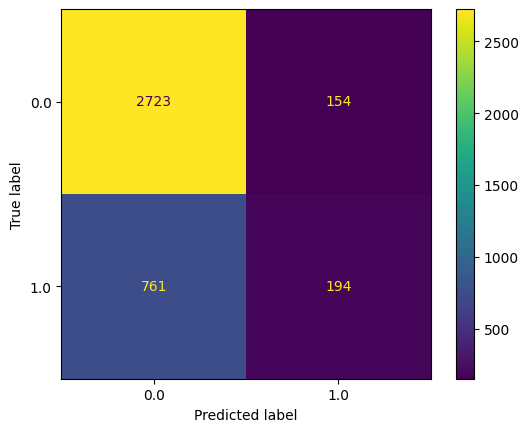

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay

# Display the confusion matrix for Logistic Regression
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr)

In [22]:
from sklearn.ensemble import RandomForestClassifier

# Create and train the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predict the target variable for the test set
y_pred_rf = rf_model.predict(X_test)

In [23]:
from sklearn.metrics import classification_report

# Evaluate the Random Forest model
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

         0.0       0.79      0.83      0.81      2877
         1.0       0.39      0.33      0.36       955

    accuracy                           0.70      3832
   macro avg       0.59      0.58      0.58      3832
weighted avg       0.69      0.70      0.69      3832



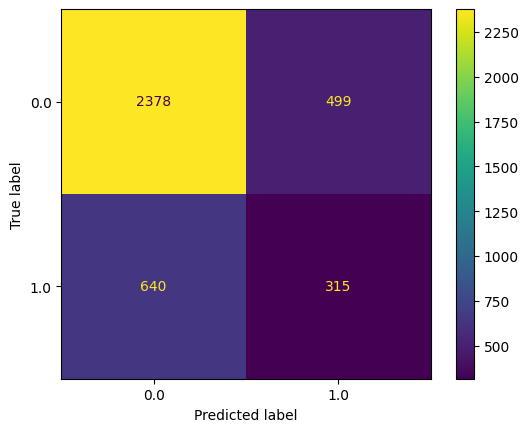

In [24]:
# Display the confusion matrix for Random Forest
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)

In [25]:
import pandas as pd

# Calculate feature importance from the Random Forest model
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# Display the top 10 most important features
feature_importance.head(10)

,0
training_hours,0.676029
experience_years,0.185647
company_type_Unknown,0.036150
education_level_High School,0.017712
company_type_Pvt Ltd,0.017006
relevent_experience_No relevent experience,0.016316
education_level_Masters,0.012086
education_level_Primary School,0.010368
education_level_Unknown,0.009291
company_type_Funded Startup,0.005385


In [26]:
# Analyze education level distribution among candidates likely to change jobs
df[df['target'] == 1]['education_level'].value_counts(normalize=True) * 100

,proportion
education_level,
Graduate,67.929663
Masters,19.572954
High School,8.247854
Unknown,2.177099
Phd,1.214151
Primary School,0.858279


In [27]:
# Calculate the job change rate for each education level
education_job_change = df.groupby('education_level')['target'].mean() * 100

education_job_change.sort_values(ascending=False)

,target
education_level,
Graduate,27.978962
Unknown,22.608696
Masters,21.440037
High School,19.533961
Phd,14.009662
Primary School,13.311688


In [28]:
# Calculate basic recruitment statistics
total_candidates = len(df)
job_change_candidates = df['target'].sum()
job_change_rate = df['target'].mean() * 100

print("Total candidates:", total_candidates)
print("Candidates likely to change jobs:", job_change_candidates)
print("Job change rate:", round(job_change_rate, 2), "%")

Total candidates: 19158
Candidates likely to change jobs: 4777.0
Job change rate: 24.93 %


In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Compare the performance of both models
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.761221,0.557471,0.203141,0.297774
1,Random Forest,0.702766,0.386978,0.329843,0.356133


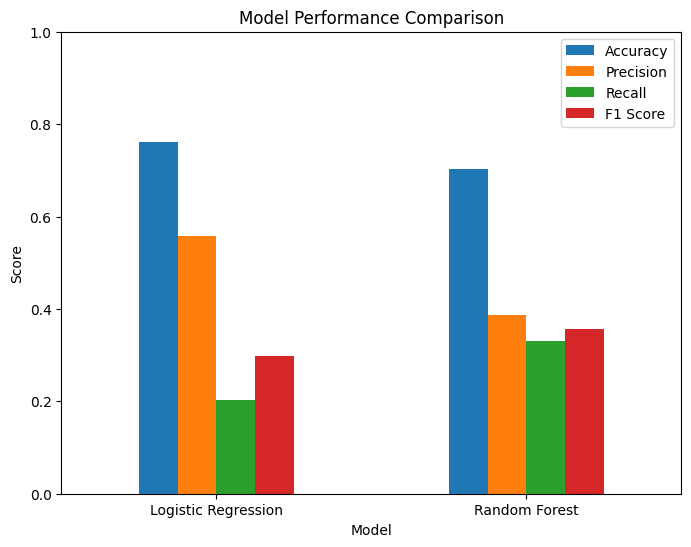

In [30]:
import matplotlib.pyplot as plt

# Compare model performance
model_comparison.set_index('Model').plot(kind='bar', figsize=(8, 6))

plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.show()

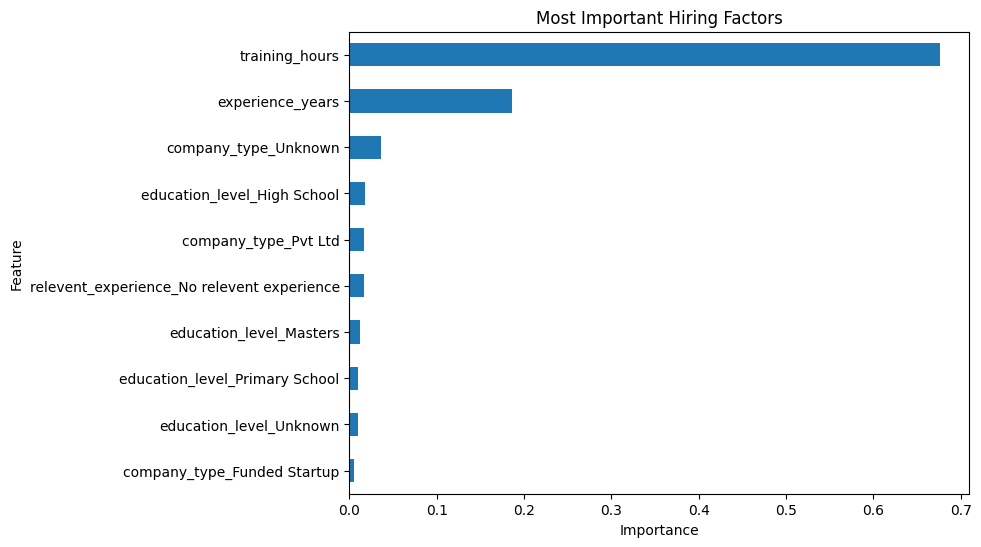

In [31]:
# Plot the most important hiring factors
feature_importance.head(10).sort_values().plot(
    kind='barh',
    figsize=(8, 6)
)

plt.title('Most Important Hiring Factors')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

# Recruitment Dashboard

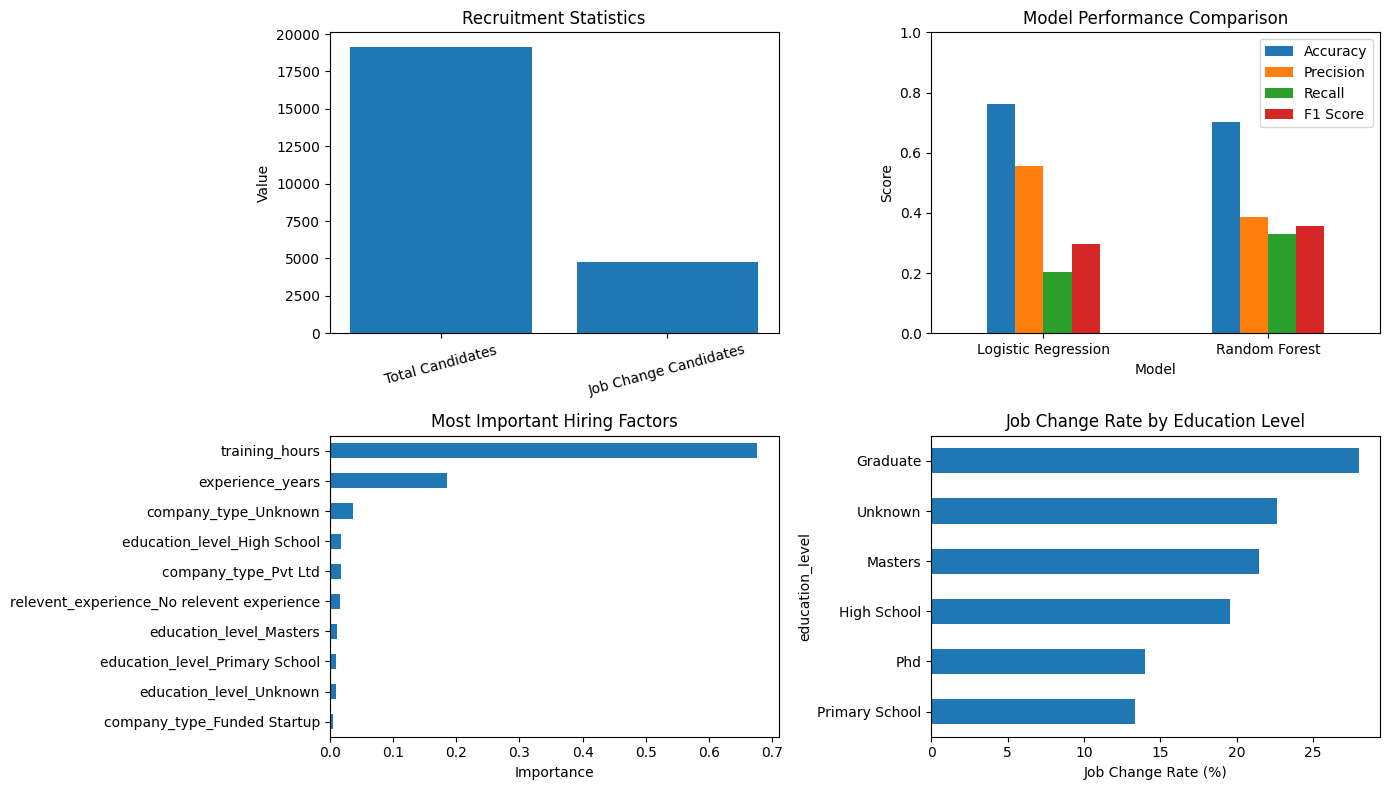

In [34]:
import matplotlib.pyplot as plt

# Create the recruitment dashboard
fig = plt.figure(figsize=(14, 8))

# 1. Recruitment Statistics
ax1 = plt.subplot(2, 2, 1)

stats = {
    'Total Candidates': total_candidates,
    'Job Change Candidates': job_change_candidates,

}

ax1.bar(stats.keys(), stats.values())
ax1.set_title('Recruitment Statistics')
ax1.set_ylabel('Value')
ax1.tick_params(axis='x', rotation=15)

# 2. Model Performance
ax2 = plt.subplot(2, 2, 2)

model_comparison.set_index('Model').plot(
    kind='bar',
    ax=ax2
)

ax2.set_title('Model Performance Comparison')
ax2.set_ylabel('Score')
ax2.set_ylim(0, 1)
ax2.tick_params(axis='x', rotation=0)

# 3. Most Important Factors
ax3 = plt.subplot(2, 2, 3)

feature_importance.head(10).sort_values().plot(
    kind='barh',
    ax=ax3
)

ax3.set_title('Most Important Hiring Factors')
ax3.set_xlabel('Importance')

# 4. Candidate Profile Trends
ax4 = plt.subplot(2, 2, 4)

education_job_change.sort_values().plot(
    kind='barh',
    ax=ax4
)

ax4.set_title('Job Change Rate by Education Level')
ax4.set_xlabel('Job Change Rate (%)')

plt.tight_layout()
plt.show()